# 04 · Weather normalisation & forecasting

**Question.** How much of each store's electricity is driven by weather, do the baseline models meet the industry standard for measurement & verification, and can we forecast next year's bills?

**Data.** Monthly electricity for the 8 focus stores (notebook 03), the wider pool of big-box stores (for the machine-learning model), and NYC monthly temperature and degree days (D3).

**Method.**
* **ASHRAE Guideline 14 change-point regression**: 2P, 3P-cooling, 3P-heating and 5P forms fitted per store on average daily kWh vs mean monthly temperature (balance points by grid search). Best form by adjusted R²; calibration checked against the monthly thresholds **CV(RMSE) ≤ 15%** and **|NMBE| ≤ 5%**.
* **Backtest** on 2024 (the last 12 published months) of three forecasters: seasonal naive, change-point + actual weather, and a pooled LightGBM. MAPE is reported per store and for the portfolio.
* **Forecast** for calendar 2025 (not yet published by the city) under typical-year weather and under the actual 2025 weather.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

from wattwise import io, viz
from wattwise.weather import fit_changepoint, best_model, ashrae_pass, typical_year, robust_changepoint
from wattwise import forecast as fc

warnings.filterwarnings("ignore")
np.random.seed(io.assumptions()["seed"])
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
viz.use_style()

T = io.assumptions()["thresholds"]
weather = io.load("weather_monthly")
monthly = io.load("monthly")
annual = io.load("annual_clean")
focus = io.load("focus_portfolio")
name = dict(zip(focus.property_id, focus.store))

elec = monthly[monthly.property_id.isin(name)].merge(weather, on="month", how="left")
elec["store"] = elec.property_id.map(name)
elec = elec.dropna(subset=["elec_kwh"])
base = elec[elec.year.isin([2023, 2024])]

# weather context
wy = weather.assign(year=weather.month.dt.year).groupby("year")[["hdd18", "cdd18", "hdd65", "cdd65"]].sum()
wy = wy[wy.index <= 2025]
wy

,hdd18,cdd18,hdd65,cdd65
year,,,,
2018,"2,797.80",659.80,"5,176.08","1,108.68"
2019,"2,759.60",602.70,"5,112.06","1,010.64"
2020,"2,507.10",636.90,"4,661.88","1,075.92"
2021,"2,542.60",636.60,"4,717.02","1,067.22"
2022,"2,690.70",681.70,"4,985.52","1,150.32"
2023,"2,369.60",547.40,"4,413.36",914.40
2024,"2,464.20",650.60,"4,575.24","1,091.16"
2025,"2,726.50",729.10,"5,047.20","1,232.88"


## 1 · Change-point models per store (baseline 2023–2024)
Baselines use a two-pass robust fit: months with gross billing errors (|robust z| > 3.5, e.g. a catch-up bill) are excluded and **listed**, as ASHRAE-14 allows for documented bad data. Every form's adjusted R² is shown so the model choice is transparent.

In [2]:
rows, models = [], {}
excluded = {}
for store, g in base.groupby("store"):
    best, keep = robust_changepoint(g.t_mean_c, g.elec_kwh, g.days)
    gk = g[keep]
    fits = fit_changepoint(gk.t_mean_c, gk.elec_kwh, gk.days)
    models[store] = best
    excluded[store] = ", ".join(g.loc[~keep, "month"].dt.strftime("%Y-%m"))
    row = {"store": store, "months used": int(keep.sum()), "excluded (bad bills)": excluded[store] or "none"}
    for k in ["2P", "3PC", "3PH", "5P"]:
        row[f"adjR² {k}"] = fits[k].adj_r2 if k in fits else np.nan
    row.update({"best": best.kind, "CV(RMSE) %": best.cvrmse * 100, "NMBE %": best.nmbe * 100,
                "ASHRAE-14": "pass" if ashrae_pass(best) else "fail",
                "base load kWh/day": best.base_load_daily, "cooling slope kWh/day/°C": best.cooling_slope,
                "heating slope kWh/day/°C": best.heating_slope,
                "Tc °C": best.params.get("Tc"), "Th °C": best.params.get("Th")})
    rows.append(row)
cp = pd.DataFrame(rows).set_index("store")
n_pass = (cp["ASHRAE-14"] == "pass").sum()
print(f"{n_pass} of {len(cp)} stores meet ASHRAE-14 monthly calibration (CV(RMSE) ≤ {T['ashrae14_cvrmse_monthly']:.0%}, |NMBE| ≤ {T['ashrae14_nmbe_monthly']:.0%})")
cp

6 of 8 stores meet ASHRAE-14 monthly calibration (CV(RMSE) ≤ 15%, |NMBE| ≤ 5%)


,months used,excluded (bad bills),adjR² 2P,adjR² 3PC,adjR² 3PH,adjR² 5P,best,CV(RMSE) %,NMBE %,ASHRAE-14,base load kWh/day,cooling slope kWh/day/°C,heating slope kWh/day/°C,Tc °C,Th °C
store,,,,,,,,,,,,,,,
Store A,24,none,0.15,0.47,0.05,0.70,5P,7.06,0.00,pass,"17,843.32",636.50,"1,180.38",16.00,5.00
Store B,24,none,0.31,0.51,NaN,0.49,3PC,33.24,-0.05,fail,"3,834.19",516.63,0.00,16.00,NaN
Store C,24,none,0.93,0.96,NaN,0.95,3PC,5.97,0.01,pass,"5,835.64",323.20,0.00,7.00,NaN
Store D,24,none,0.79,0.95,NaN,0.95,3PC,3.38,0.01,pass,"5,014.08",182.83,0.00,13.50,NaN
Store E,23,2023-08,0.25,NaN,0.30,0.24,3PH,21.49,-0.08,fail,"5,767.30",0.00,200.01,NaN,15.50
Store F,24,none,0.20,0.56,-0.02,0.67,5P,8.15,0.01,pass,"3,875.98",165.48,91.57,15.50,10.00
Store G,22,"2023-08, 2023-09",0.53,0.78,NaN,0.78,3PC,7.09,0.01,pass,"4,166.48",165.07,0.00,15.50,NaN
Store H,21,"2024-05, 2024-06, 2024-12",0.78,0.96,NaN,0.96,5P,4.37,0.00,pass,"4,762.31",276.08,47.24,12.00,10.00


In [3]:
# weather-sensitive share of annual electricity: consumption above the base load
ws = {}
for store, g in base.groupby("store"):
    m = models[store]
    base_kwh = m.base_load_daily * g.days.sum()  # base load × days, vs modelled total
    ws[store] = 1 - base_kwh / m.predict(g.t_mean_c, g.days).sum()
cp["weather-sensitive share %"] = pd.Series(ws) * 100
cool_share_median = cp["weather-sensitive share %"].median()
cp[["best", "weather-sensitive share %", "cooling slope kWh/day/°C", "Tc °C"]]

,best,weather-sensitive share %,cooling slope kWh/day/°C,Tc °C
store,,,,
Store A,5P,10.01,636.50,16.00
Store B,3PC,22.90,516.63,16.00
Store C,3PC,28.26,323.20,7.00
Store D,3PC,10.85,182.83,13.50
Store E,3PH,14.45,0.00,NaN
Store F,5P,13.39,165.48,15.50
Store G,3PC,8.68,165.07,15.50
Store H,5P,20.68,276.08,12.00


## 2 · Energy signatures
Each dot is one month: average daily electricity vs mean outdoor temperature. The line is the selected change-point model; the kink is the balance point where cooling (or heating) starts.

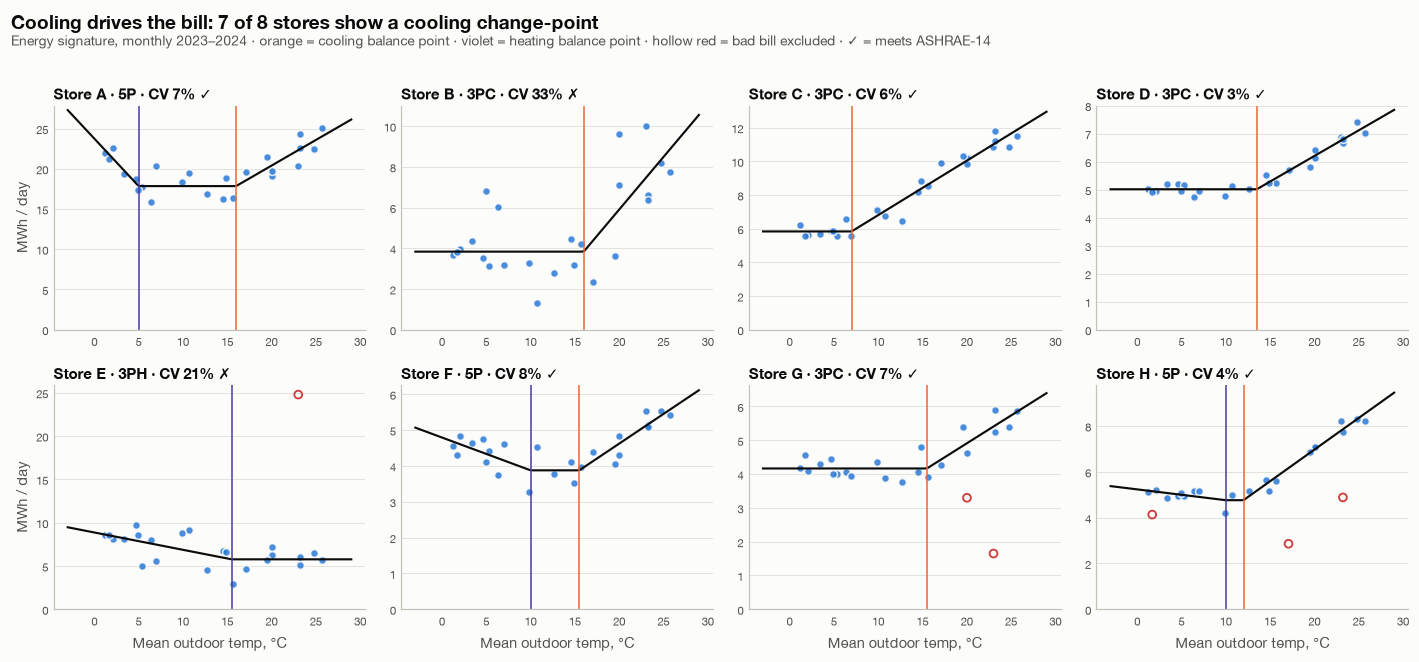

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.8))
tgrid = np.linspace(-3, 29, 120)
for ax, store in zip(axes.flat, sorted(models)):
    g = base[base.store == store]
    m = models[store]
    bad = g.month.dt.strftime("%Y-%m").isin(excluded[store].split(", ")) if excluded[store] else pd.Series(False, index=g.index)
    ax.scatter(g.t_mean_c[~bad], (g.elec_kwh / g.days / 1e3)[~bad], s=26, color=viz.BLUE, alpha=0.85, edgecolor=viz.SURFACE, linewidth=1)
    ax.scatter(g.t_mean_c[bad], (g.elec_kwh / g.days / 1e3)[bad], s=26, facecolor="none", edgecolor=viz.CRITICAL, linewidth=1.2)
    ax.plot(tgrid, m.predict_daily(tgrid) / 1e3, color=viz.INK, linewidth=1.4)
    if m.params.get("Tc") is not None:
        ax.axvline(m.params["Tc"], color=viz.ORANGE, linewidth=1)
    if m.params.get("Th") is not None:
        ax.axvline(m.params["Th"], color=viz.VIOLET, linewidth=1)
    status = "✓" if ashrae_pass(m) else "✗"
    ax.set_title(f"{store} · {m.kind} · CV {m.cvrmse:.0%} {status}", fontsize=9.5, pad=4)
    ax.set_ylim(0, None)
    ax.tick_params(labelsize=7.5)
for ax in axes[1]:
    ax.set_xlabel("Mean outdoor temp, °C")
for ax in axes[:, 0]:
    ax.set_ylabel("MWh / day")
fig.suptitle(f"Cooling drives the bill: {sum(models[s].kind in ('3PC', '5P') for s in models)} of 8 stores show a cooling change-point",
             x=0.01, ha="left", fontsize=12.5, fontweight="bold", y=1.03)
fig.text(0.01, 0.975, "Energy signature, monthly 2023–2024 · orange = cooling balance point · violet = heating balance point · hollow red = bad bill excluded · ✓ = meets ASHRAE-14",
         color=viz.INK_2, fontsize=9)
fig.tight_layout()
viz.save(fig, "04_energy_signatures")
plt.show()

## 3 · Backtest: forecasting 2024 from data available at the end of 2023
* **Seasonal naive**: 2024 month = same month in 2023.
* **Change-point + weather**: each store's model fitted on 2023 only, driven by actual 2024 temperatures.
* **LightGBM (pooled)**: one model trained on every big-box store's monthly history 2018–2023 (2020 excluded as an abnormal COVID year), with features calendar month, temperature, HDD/CDD, store size and the store's own value 12 months earlier.

All three forecast the same 96 store-months of the focus portfolio.

In [5]:
test_year, train_year = 2024, 2023
bt = []
for store, g in elec.groupby("store"):
    tr, te = g[g.year == train_year].sort_values("month"), g[g.year == test_year].sort_values("month")
    cp_pred, _ = fc.changepoint_forecast(tr, te, "elec_kwh")
    bt.append(te[["store", "property_id", "month", "elec_kwh"]].assign(
        seasonal_naive=fc.seasonal_naive(tr, te, "elec_kwh"), changepoint=cp_pred))
bt = pd.concat(bt, ignore_index=True)

# LightGBM pool: every big-box store with monthly data and a floor area
gfa = annual.sort_values("year").groupby("property_id").gfa_ft2.last()
bb_ids = annual.loc[annual.cohort == "Big-box retail", "property_id"].unique()
pool = monthly[monthly.property_id.isin(bb_ids)].merge(weather, on="month", how="left")
pool["gfa_ft2"] = pool.property_id.map(gfa)
pool = pool.dropna(subset=["elec_kwh", "gfa_ft2"])
pool = pool[pool.elec_kwh > 0]
lgb_te, lgb_model = fc.lightgbm_backtest(pool, "elec_kwh", test_year, [2018, 2019, 2021, 2023])
bt = bt.merge(lgb_te[["property_id", "month", "pred"]].rename(columns={"pred": "lightgbm"}), on=["property_id", "month"], how="left")
print(f"LightGBM trained on {pool[pool.month.dt.year.isin([2018, 2019, 2021, 2023])].property_id.nunique()} stores, "
      f"{len(pool[pool.month.dt.year.isin([2018, 2019, 2021, 2023])]):,} store-months")

methods = ["seasonal_naive", "changepoint", "lightgbm"]
per_store = bt.groupby("store").apply(lambda d: pd.Series({m: fc.mape(d.elec_kwh, d[m]) for m in methods}))
port = bt.groupby("month")[["elec_kwh"] + methods].sum()
per_store.loc["Portfolio (sum of stores)"] = [fc.mape(port.elec_kwh, port[m]) for m in methods]
per_store.loc["Median store"] = per_store.iloc[:-1].median()
clean_stores = cp.index[cp["ASHRAE-14"] == "pass"]
per_store.loc["Median, ASHRAE-pass stores"] = per_store.loc[clean_stores].median()
per_store.columns = ["Seasonal naive", "Change-point + weather", "LightGBM (pooled)"]
annual_err = {m: (bt[m].sum() / bt.elec_kwh.sum() - 1) * 100 for m in methods}
print("Monthly MAPE, %  (lower is better)")
per_store

LightGBM trained on 475 stores, 14,925 store-months
Monthly MAPE, %  (lower is better)


,Seasonal naive,Change-point + weather,LightGBM (pooled)
store,,,
Store A,14.16,10.18,5.56
Store B,53.73,65.09,40.90
Store C,6.18,6.68,8.04
Store D,4.30,6.73,7.86
Store E,41.68,14.99,25.00
Store F,10.44,12.05,22.62
Store G,15.46,9.02,14.36
Store H,18.86,20.92,20.22
Portfolio (sum of stores),5.93,4.38,3.58


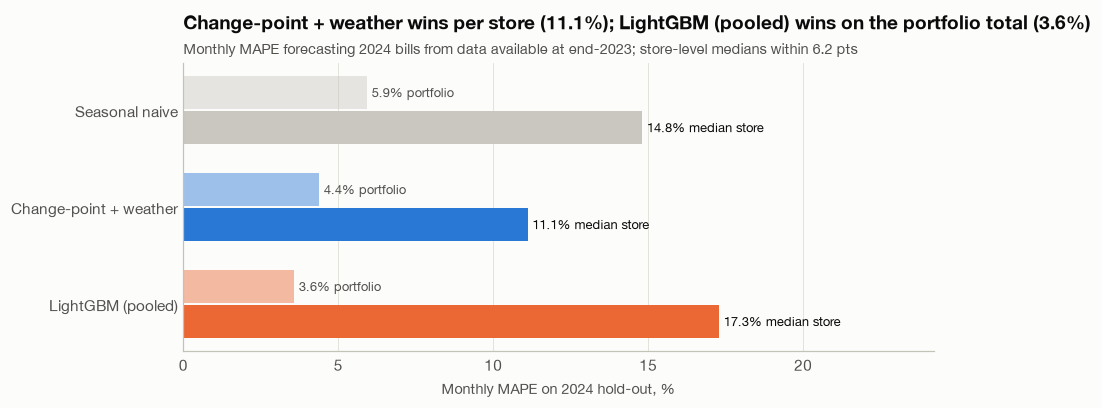

In [6]:
fig, ax = plt.subplots(figsize=(8.8, 3.4))
med = per_store.loc["Median store"]
portm = per_store.loc["Portfolio (sum of stores)"]
y = np.arange(3)
colors = [viz.CONTEXT, viz.BLUE, viz.ORANGE]
ax.barh(y + 0.18, med.values, height=0.34, color=colors, label="Median store")
ax.barh(y - 0.18, portm.values, height=0.34, color=colors, alpha=0.45, label="Portfolio total")
for i, (a_, b_) in enumerate(zip(med.values, portm.values)):
    ax.text(a_ + 0.15, i + 0.18, f"{a_:.1f}% median store", va="center", fontsize=8.5)
    ax.text(b_ + 0.15, i - 0.18, f"{b_:.1f}% portfolio", va="center", fontsize=8.5, color=viz.INK_2)
ax.set_yticks(y, med.index)
ax.invert_yaxis()
ax.set_xlabel("Monthly MAPE on 2024 hold-out, %")
ax.set_xlim(0, max(med.max(), portm.max()) * 1.4)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
best_method = med.idxmin()
best_port = portm.idxmin()
spread = med.max() - med.min()
viz.title(ax, f"{best_method} wins per store ({med.min():.1f}%); {best_port} wins on the portfolio total ({portm.min():.1f}%)",
          f"Monthly MAPE forecasting 2024 bills from data available at end-2023; store-level medians within {spread:.1f} pts")
viz.save(fig, "04_backtest_mape")
plt.show()

## 4 · Forecast for calendar 2025
The city has not yet published 2025 bills. Each store's change-point model, refitted on 2023–2024, is driven by
(a) **typical-year weather** (monthly averages 2018–2024), the budget view, and
(b) the **actual 2025 weather** (already observed), which is the benchmark to check 2025 bills against when they arrive.
The band is ±1.96 × the portfolio's monthly RMSE from the 2024 change-point backtest.

In [7]:
ty = typical_year(weather, list(range(2018, 2025)))
w25 = weather[weather.month.dt.year == 2025].copy()
w25["cal_month"] = w25.month.dt.month
w25 = w25.merge(ty[["cal_month", "t_mean_c"]].rename(columns={"t_mean_c": "t_typical"}), on="cal_month")
fc_rows = []
for store, m in models.items():
    fc_rows.append(pd.DataFrame({"store": store, "month": w25.month,
                                 "typical": m.predict(w25.t_typical, w25.days),
                                 "actual_weather": m.predict(w25.t_mean_c, w25.days)}))
f25 = pd.concat(fc_rows)
p25 = f25.groupby("month")[["typical", "actual_weather"]].sum()
hist = base.groupby("month").elec_kwh.sum()
rmse = np.sqrt(((port.elec_kwh - port.changepoint) ** 2).mean())
weather_effect = p25.actual_weather.sum() / p25.typical.sum() - 1
cdd_2025, cdd_typ = w25.cdd18.sum(), ty.cdd18.sum()
print(f"2025 forecast, 8 stores: {p25.typical.sum() / 1e6:,.1f} GWh (typical weather) vs {p25.actual_weather.sum() / 1e6:,.1f} GWh (actual 2025 weather), "
      f"weather effect {weather_effect:+.1%}; 2025 CDD18 {cdd_2025:,.0f} vs typical {cdd_typ:,.0f}")

2025 forecast, 8 stores: 22.2 GWh (typical weather) vs 22.8 GWh (actual 2025 weather), weather effect +2.9%; 2025 CDD18 729 vs typical 631


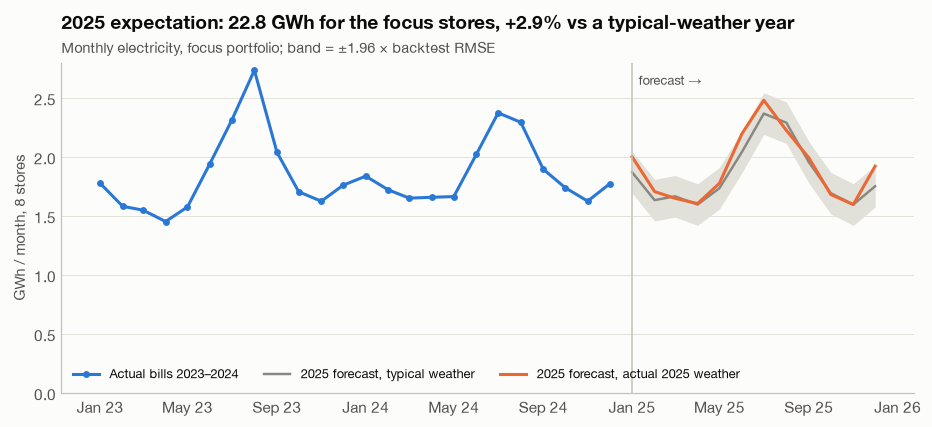

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.9))
ax.plot(hist.index, hist / 1e6, color=viz.BLUE, marker="o", markersize=3.5, label="Actual bills 2023–2024")
ax.plot(p25.index, p25.typical / 1e6, color=viz.MUTED, linewidth=1.6, label="2025 forecast, typical weather")
ax.fill_between(p25.index, (p25.typical - 1.96 * rmse) / 1e6, (p25.typical + 1.96 * rmse) / 1e6, color=viz.GRID, linewidth=0)
ax.plot(p25.index, p25.actual_weather / 1e6, color=viz.ORANGE, linewidth=2, label="2025 forecast, actual 2025 weather")
ax.axvline(pd.Timestamp("2025-01-01"), color=viz.AXIS, linewidth=1)
ax.text(pd.Timestamp("2025-01-10"), ax.get_ylim()[1] * 0.97, "forecast →", fontsize=8.5, color=viz.INK_2, va="top")
ax.set_ylabel("GWh / month, 8 stores")
ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax.legend(loc="lower left", fontsize=8.5, ncols=3)
viz.title(ax, f"2025 expectation: {p25.actual_weather.sum() / 1e6:,.1f} GWh for the focus stores, {weather_effect:+.1%} vs a typical-weather year",
          "Monthly electricity, focus portfolio; band = ±1.96 × backtest RMSE")
viz.save(fig, "04_forecast_2025")
plt.show()

In [9]:
cp.reset_index().to_parquet(io.PROCESSED / "changepoint_models.parquet", index=False)
f25.to_parquet(io.PROCESSED / "forecast_2025.parquet", index=False)
io.save_result("04_forecast", {
    "ashrae_pass": int(n_pass), "stores": len(cp),
    "cooling_changepoint_stores": int(sum(models[s].kind in ("3PC", "5P") for s in models)),
    "median_cvrmse_pct": float(cp["CV(RMSE) %"].median()),
    "weather_sensitive_share_median_pct": float(cool_share_median),
    "cooling_slope_kwh_day_c": cp["cooling slope kWh/day/°C"].to_dict(),
    "mape_median_store": per_store.loc["Median store"].to_dict(),
    "mape_portfolio": per_store.loc["Portfolio (sum of stores)"].to_dict(),
    "annual_error_pct": annual_err,
    "best_method_median_store": best_method,
    "best_method_portfolio": best_port,
    "mape_clean_stores": per_store.loc["Median, ASHRAE-pass stores"].to_dict(),
    "excluded_baseline_months": excluded,
    "forecast_2025_typical_gwh": float(p25.typical.sum() / 1e6),
    "forecast_2025_actual_weather_gwh": float(p25.actual_weather.sum() / 1e6),
    "weather_effect_2025": float(weather_effect),
    "cdd18_2025": float(cdd_2025), "cdd18_typical": float(cdd_typ),
    "lgb_train_stores": int(pool[pool.month.dt.year.isin([2018, 2019, 2021, 2023])].property_id.nunique()),
})

In [10]:
nm, cpm_, lg = per_store.loc["Median store"]
pn, pc, pl = per_store.loc["Portfolio (sum of stores)"]
cn, cc, cl = per_store.loc["Median, ASHRAE-pass stores"]
tix = io.load("facility_tickets") if (io.PROCESSED / "facility_tickets.parquet").exists() else pd.DataFrame()
fail = cp.index[cp["ASHRAE-14"] == "fail"].tolist()
bill_counts = tix[tix.ticket_type == "Billing / meter check"].groupby("store").size().reindex(fail).fillna(0).astype(int) if len(tix) else pd.Series(dtype=int)
worst = per_store.iloc[:8]["Change-point + weather"].nlargest(2).index.tolist()
display(Markdown(f"""
## Key findings
1. **{n_pass} of {len(cp)} baselines are M&V-grade.** These stores meet ASHRAE Guideline 14 monthly calibration (CV(RMSE) ≤ 15%, |NMBE| ≤ 5%), good enough to verify savings under IPMVP Option C. The failing stores ({', '.join(f'{s}: {bill_counts.get(s, 0)} billing tickets' for s in fail)}) have irregular bills that weather can't explain. Their meters need fixing before their savings can be verified.
2. **Cooling is the swing load.** {sum(models[s].kind in ('3PC', '5P') for s in models)} of 8 stores show a cooling change-point. In the median store {cool_share_median:.0f}% of electricity is weather-sensitive. The rest is base load, which runs all year (notebook 05).
3. **No forecaster dominates, and data quality limits accuracy more than model choice.** For the **portfolio total**, monthly MAPE is {pl:.1f}% (LightGBM) vs {pc:.1f}% (change-point) vs {pn:.1f}% (seasonal naive). For the **median store**: {cpm_:.1f}% / {lg:.1f}% / {nm:.1f}% (change-point / LightGBM / naive). On the clean, ASHRAE-passing stores the change-point model reaches {cc:.1f}% with nothing to tune. The largest store errors ({', '.join(f'{w}: {int(tix[(tix.store == w) & (tix.ticket_type == "Billing / meter check")].shape[0])} billing tickets' for w in worst)}) are at stores with irregular bills, so cleaning the data would improve accuracy more than a bigger model.
4. **2025 expectation.** With 2025's actual weather (CDD18 {cdd_2025:,.0f} vs typical {cdd_typ:,.0f}, a hotter summer) the 8 stores should use **{p25.actual_weather.sum() / 1e6:,.1f} GWh**, {weather_effect:+.1%} vs a typical year. When the city publishes 2025 bills, months outside the band are the next audit list.
"""))


## Key findings
1. **6 of 8 baselines are M&V-grade.** These stores meet ASHRAE Guideline 14 monthly calibration (CV(RMSE) ≤ 15%, |NMBE| ≤ 5%), good enough to verify savings under IPMVP Option C. The failing stores (Store B: 2 billing tickets, Store E: 9 billing tickets) have irregular bills that weather can't explain. Their meters need fixing before their savings can be verified.
2. **Cooling is the swing load.** 7 of 8 stores show a cooling change-point. In the median store 14% of electricity is weather-sensitive. The rest is base load, which runs all year (notebook 05).
3. **No forecaster dominates, and data quality limits accuracy more than model choice.** For the **portfolio total**, monthly MAPE is 3.6% (LightGBM) vs 4.4% (change-point) vs 5.9% (seasonal naive). For the **median store**: 11.1% / 17.3% / 14.8% (change-point / LightGBM / naive). On the clean, ASHRAE-passing stores the change-point model reaches 9.6% with nothing to tune. The largest store errors (Store B: 2 billing tickets, Store H: 4 billing tickets) are at stores with irregular bills, so cleaning the data would improve accuracy more than a bigger model.
4. **2025 expectation.** With 2025's actual weather (CDD18 729 vs typical 631, a hotter summer) the 8 stores should use **22.8 GWh**, +2.9% vs a typical year. When the city publishes 2025 bills, months outside the band are the next audit list.
